In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from tkinter.messagebox import IGNORE
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.vector_ar.var_model import VAR
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# --- Semilla para reproducibilidad ---
SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()


c:\Users\Usuario\Documents\MAESTRÍA\Semestre 2\Deep learning\condapython3_9\.conda\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [39]:
#leer el dataset
df_r1 = pd.read_csv('C:\\Users\\Usuario\\Documents\\GitHub\\PROYECTO_MAESTRÍA\\Prediccion-Cizalladura-SKBQ\\docs\\notebooks\\DATOS_CUMPLIMIENTO_R1.csv', index_col=0, parse_dates=True)
df_r1.head()

,dir_sin,dir_cos,intensidad_kt,temperatura,rocio
FECHA_REPORTE,,,,,
2013-01-01 00:00:00,0.173648,0.984808,3.0,14.0,6.0
2013-01-01 01:00:00,0.500000,0.866025,5.0,13.0,7.0
2013-01-01 02:00:00,0.939693,0.342020,3.0,13.0,7.0
2013-01-01 03:00:00,0.500000,0.866025,3.0,10.0,7.0
2013-01-01 04:00:00,0.500000,0.866025,4.0,9.0,7.0


In [40]:
df_r1.head()

,dir_sin,dir_cos,intensidad_kt,temperatura,rocio
FECHA_REPORTE,,,,,
2013-01-01 00:00:00,0.173648,0.984808,3.0,14.0,6.0
2013-01-01 01:00:00,0.500000,0.866025,5.0,13.0,7.0
2013-01-01 02:00:00,0.939693,0.342020,3.0,13.0,7.0
2013-01-01 03:00:00,0.500000,0.866025,3.0,10.0,7.0
2013-01-01 04:00:00,0.500000,0.866025,4.0,9.0,7.0


Mes con más ráfagas: 2019-08 (160 ráfagas)


year_month
2019-08    160
2017-07    149
2013-07    143
2014-07    140
2024-09    140
2014-08    134
2013-08    134
2015-06    132
2015-08    131
2016-08    119
dtype: int64

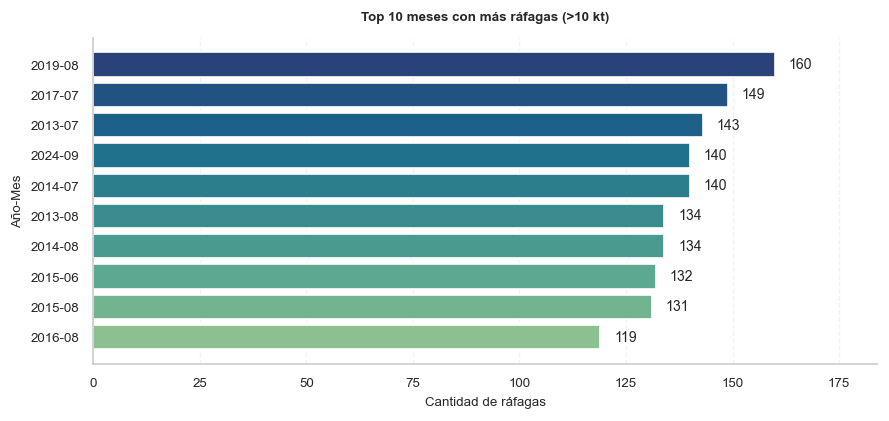

In [68]:
from IPython.display import display

# Determinar año-mes con mayor cantidad de ráfagas (>19 kt)
df_r1['year_month'] = df_r1.index.to_period('M').astype(str)
rafagas = df_r1[df_r1['intensidad_kt'] > 10]
counts = rafagas.groupby('year_month').size().sort_values(ascending=False)
if not counts.empty:
    top_month = counts.index[0]
    top_count = int(counts.iloc[0])
    print(f"Mes con más ráfagas: {top_month} ({top_count} ráfagas)")
    mes_str = top_month
    df_mes = df_r1.loc[mes_str]
    top10 = counts.head(10).sort_values()
    display(top10.sort_values(ascending=False))

    # Gráfico más pequeño y elegante
    sns.set_theme(style='whitegrid', context='paper')
    fig, ax = plt.subplots(figsize=(7.5, 3.6), dpi=120)
    colors = sns.color_palette('crest', n_colors=len(top10))
    bars = ax.barh(top10.index, top10.values, color=colors, edgecolor='white', linewidth=1)

    ax.set_title('Top 10 meses con más ráfagas (>10 kt)', pad=10, fontsize=8, fontweight='bold')
    ax.set_xlabel('Cantidad de ráfagas', fontsize=8)
    ax.set_ylabel('Año-Mes', fontsize=8)
    ax.tick_params(axis='both', labelsize=8)
    ax.grid(axis='x', linestyle='--', alpha=0.25)
    ax.grid(axis='y', visible=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar in bars:
        width = bar.get_width()
        ax.text(width + max(top10.values) * 0.02, bar.get_y() + bar.get_height() / 2,
                f'{int(width)}', va='center', ha='left', fontsize=8.5)

    ax.set_xlim(0, max(top10.values) * 1.15)
    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron ráfagas >10 kt en el dataset.')

In [70]:
#distribución de datos intensidades > 10kt vs total de datos
rafagas = df_r1[df_r1['intensidad_kt'] > 10]
total_datos = len(df_r1)
print(f"Ráfagas >10 kt: {len(rafagas)}")
print(f"Total de datos: {total_datos}")
print(f"Porcentaje de ráfagas >10 kt: {len(rafagas) / total_datos:.4%}")


Ráfagas >10 kt: 9703
Total de datos: 116323
Porcentaje de ráfagas >10 kt: 8.3414%


In [ ]:
#Cargar el modelo LSTM entrenado
import pickle
import os
from tensorflow.keras.models import model_from_json
import tensorflow as tf

@tf.keras.utils.register_keras_serializable()

def circular_loss(y_true, y_pred):
    """
    Función de pérdida personalizada que maneja la naturaleza circular de la dirección del viento
    y pondera adecuadamente el error direccional y el error de intensidad
    """
    # Error en sin y cos (captura circularidad automáticamente)
    error_sin = tf.square(y_true[:, 0] - y_pred[:, 0])
    error_cos = tf.square(y_true[:, 1] - y_pred[:, 1])
    error_dir = error_sin + error_cos  # equivalente al error angular en el círculo unitario

    # Error en intensidad
    error_int = tf.square(y_true[:, 2] - y_pred[:, 2])

    # Peso mayor a dirección si quieres priorizar ese error
    return tf.reduce_mean(3*error_dir + error_int)

#cargar el modelo entrenado
model_lstm = load_model('best_model_20h.h5', custom_objects={'circular_loss': circular_loss})

In [44]:
import joblib
# Cargar scalers
scaler_X = joblib.load('scaler_X.pkl')
scaler_y = joblib.load('scaler_y.pkl')


In [45]:
#función para predecir de forma autoregresiva
def predict_autoregressive(modelo, initial_window, exog_future, horizon):
    """
    Realiza el pronóstico iterativo hacia el futuro.
    - initial_window: Array con forma (1, n_back, n_features). Ej: (1, 48, 5)
    - exog_future: Variables exógenas futuras (temperatura y rocio). Forma (horizon, 2)
    - horizon: Cantidad de pasos a predecir (6 horas)
    """
    current_window = np.copy(initial_window)
    predictions = []
    
    for i in range(horizon):
        
        # 1. Predecir dir_sin, dir_cos, intensidad_log
        next_uv = modelo.predict(current_window, verbose=0)  # (1, 3)
        
        predictions.append(next_uv[0])
        
        # 2. Tomar temperatura y rocío reales futuros
        temp_rocio = exog_future[i]  # (2,)
        
        # 3. Construir el nuevo timestep completo (5 variables)
        next_step_full = np.concatenate([next_uv[0], temp_rocio])  # (5,)
        
        # 4. Expandir a 3D
        next_step_full_3d = next_step_full.reshape(1, 1, 5)
        
        # 5. Actualizar ventana
        current_window = np.concatenate(
            [current_window[:, 1:, :], next_step_full_3d],
            axis=1
        )
    
    return np.array(predictions)  # (horizon, 3)


validación R1

In [64]:
# Asignarlo mes con más ráfagas:
#mes_max = pd.Timestamp('2014-07-01')
mes_str = '2019-08'
UMBRAL_RAFAGA = 10  # kt, umbral para considerar ráfaga significativa
df_mes = df_r1.loc[mes_str]
n_back = 20  # horas previas para la ventana de entrada
horizonte_pred = 3  # horas a predecir (H+6)
features_modelo = ['dir_sin', 'dir_cos', 'intensidad_kt', 'temperatura', 'rocio']

# extraer 20h previas al mes para la primera ventana
fecha_inicio_ventana = df_mes.index[0] - pd.Timedelta(hours=n_back)
df_contexto = df_r1.loc[fecha_inicio_ventana:]

# Escalar con los scalers ya entrenados (sin refitear)
X_mes = scaler_X.transform(df_contexto[features_modelo].to_numpy())

# Simular predicción hora a hora (rolling forecast)
resultados_whatif = []

for t in range(n_back, n_back + len(df_mes) - horizonte_pred + 1):
    
    # Ventana de entrada
    ventana = np.expand_dims(X_mes[t - n_back:t], axis=0)
    
    # Variables exógenas futuras (temperatura y rocío reales)
    exog = X_mes[t:t + horizonte_pred, 3:]
    
    # Predicción
    forecast_esc = predict_autoregressive(model_lstm, ventana, exog, horizonte_pred)
    forecast_inv = scaler_y.inverse_transform(forecast_esc)
    
    # Hora actual (T=0) y hora de la ráfaga predicha (T+6)
    hora_actual  = df_contexto.index[t]
    hora_rafaga  = df_contexto.index[t + horizonte_pred - 1]
    int_pred_h6  = forecast_inv[-1, 2]  # H+6
    
    resultados_whatif.append({
        'hora_prediccion': hora_actual,
        'hora_objetivo':   hora_rafaga,
        'int_pred_h6':     int_pred_h6,
        'int_real_h6':     df_contexto['intensidad_kt'].iloc[t + horizonte_pred - 1],
        'alerta_pred':     int_pred_h6 > UMBRAL_RAFAGA,
        'rafaga_real':     df_contexto['intensidad_kt'].iloc[t + horizonte_pred - 1] > UMBRAL_RAFAGA,
    })

df_whatif = pd.DataFrame(resultados_whatif)

In [55]:
df_whatif[df_whatif['int_real_h6'] > 10]

,hora_prediccion,hora_objetivo,int_pred_h6,int_real_h6,alerta_pred,rafaga_real
60,2019-08-03 12:00:00,2019-08-03 17:00:00,5.879662,16.0,False,True
61,2019-08-03 13:00:00,2019-08-03 18:00:00,7.592115,15.0,False,True
62,2019-08-03 14:00:00,2019-08-03 19:00:00,7.684953,16.0,False,True
63,2019-08-03 15:00:00,2019-08-03 20:00:00,6.786260,17.0,False,True
64,2019-08-03 16:00:00,2019-08-03 21:00:00,5.195829,15.0,False,True
...,...,...,...,...,...,...
689,2019-08-29 17:00:00,2019-08-29 22:00:00,12.451305,13.0,True,True
690,2019-08-29 18:00:00,2019-08-29 23:00:00,10.883750,13.0,True,True
710,2019-08-30 14:00:00,2019-08-30 19:00:00,9.738181,14.0,False,True
713,2019-08-30 17:00:00,2019-08-30 22:00:00,7.697485,12.0,False,True


In [69]:
df_whatif.describe()

,hora_prediccion,hora_objetivo,int_pred_h6,int_real_h6
count,742,742,742.000000,742.000000
mean,2019-08-16 10:30:00,2019-08-16 12:30:00,6.620687,6.824798
min,2019-08-01 00:00:00,2019-08-01 02:00:00,2.185675,0.000000
25%,2019-08-08 17:15:00,2019-08-08 19:15:00,3.830473,3.000000
50%,2019-08-16 10:30:00,2019-08-16 12:30:00,5.351726,5.000000
75%,2019-08-24 03:45:00,2019-08-24 05:45:00,8.858433,10.000000
max,2019-08-31 21:00:00,2019-08-31 23:00:00,15.670981,26.000000
std,NaN,NaN,3.402840,4.396773


Calcular % de detección temprana

In [65]:
# Solo evaluar sobre horas donde SÍ hubo ráfaga real
eventos_reales = df_whatif[df_whatif['rafaga_real'] == True]

total_eventos   = len(eventos_reales)
detectados      = eventos_reales['alerta_pred'].sum()
pct_deteccion   = (detectados / total_eventos) * 100

print(f"=== ANÁLISIS WHAT-IF: {mes_str} ===")
print(f"Total eventos de ráfaga reales (>10kt): {total_eventos}")
print(f"Detectados 6h antes:                    {detectados}")
print(f"% Detección temprana:                   {pct_deteccion:.1f}%")
print(f"Requerimiento cumplido (≥80%):          {'✅ SÍ' if pct_deteccion >= 80 else '❌ NO'}")

# Detalle hora a hora
print("\n--- DETALLE ---")
print(df_whatif[df_whatif['rafaga_real'] == True][
    ['hora_prediccion', 'hora_objetivo', 'int_real_h6', 'int_pred_h6', 'alerta_pred']
].to_string(index=False))

=== ANÁLISIS WHAT-IF: 2019-08 ===
Total eventos de ráfaga reales (>10kt): 160
Detectados 6h antes:                    104
% Detección temprana:                   65.0%
Requerimiento cumplido (≥80%):          ❌ NO

--- DETALLE ---
    hora_prediccion       hora_objetivo  int_real_h6  int_pred_h6  alerta_pred
2019-08-03 15:00:00 2019-08-03 17:00:00         16.0     6.618803        False
2019-08-03 16:00:00 2019-08-03 18:00:00         15.0     8.230146        False
2019-08-03 17:00:00 2019-08-03 19:00:00         16.0     7.546360        False
2019-08-03 18:00:00 2019-08-03 20:00:00         17.0     9.206682        False
2019-08-03 19:00:00 2019-08-03 21:00:00         15.0     8.604691        False
2019-08-03 20:00:00 2019-08-03 22:00:00         11.0     8.246464        False
2019-08-03 21:00:00 2019-08-03 23:00:00         13.0     8.138927        False
2019-08-04 13:00:00 2019-08-04 15:00:00         14.0     9.390072        False
2019-08-04 15:00:00 2019-08-04 17:00:00         14.0    13.